Maximum iterations:  3900


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


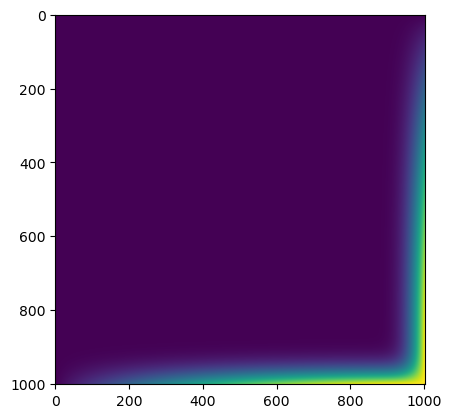

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
# from mpi4py import MPI

# comm = MPI.COMM_WORLD
# rank = comm.Get_rank()
# size = comm.Get_size()

ROWS , COLUMNS = 1000 , 1000
MAX_TEMP_ERROR = 0.01
temperature = np.empty(( ROWS+2 , COLUMNS+2 ))
temperature_last = np.empty(( ROWS+2 ,COLUMNS+2  ))


def initialize_temperature(temp):
    temp[:,:] = 0
    
    #Set right side boundary condition
    for i in range(ROWS+1):
        temp[ i , COLUMNS+1 ] = 100 * math.sin( ( (3.14159/2) /ROWS) * i )

    #Set bottom boundary condition
    for i in range(COLUMNS+1):
        temp[ ROWS+1 , i ]    = 100 * math.sin( ( (3.14159/2) /COLUMNS ) * i )
        

def output(data):
    plt.imshow(data)
    data.tofile("plate_original.out")

initialize_temperature(temperature_last)
max_iterations = int (input("Maximum iterations: "))

dt = 100
iteration = 1

while ( dt > MAX_TEMP_ERROR ) and ( iteration < max_iterations ):
    
    for i in range( 1 , ROWS+1 ):
        for j in range( 1 , COLUMNS+1 ):
            temperature[ i , j ] = 0.25 * ( temperature_last[i+1,j] + temperature_last[i-1,j] +
                                            temperature_last[i,j+1] + temperature_last[i,j-1]   )
    dt = 0

    for i in range( 1 , ROWS+1 ):
        for j in range( 1 , COLUMNS+1 ):
            dt = max( dt, temperature[i,j] - temperature_last[i,j])
            temperature_last[ i , j ] = temperature [ i , j ]
            
    print(iteration)
    iteration += 1
            
output(temperature_last)

In [5]:
from mpi4py import MPI
import numpy as np
import math
import time 

# --- Global sizes and variables ---
ROWS , COLUMNS = 1000 , 1000
MAX_TEMP_ERROR = 0.01

# --- Initialize MPI --- 
comm  = MPI.COMM_WORLD
rank  = comm.Get_rank()
size  = comm.Get_size()

# --- Decompose rows across ranks (block distribution) ---
rows_per = ROWS // size

# Global interior row index for this rank (1-based interior indexing)
# Rows 1-250, 251-500, 501-750, 751-1000
local_n = rows_per
start_i = 1 + rank * rows_per 
end_i   = start_i + rows_per - 1 

# --- Initialize temperature data ---
temperature      = np.zeros(( local_n + 2 , COLUMNS+2 ), dtype=float)
temperature_last = np.zeros(( local_n + 2 , COLUMNS+2 ), dtype=float)

# --- Set boundary columns (left/right) on all ranks ---
# left boundary j=0 is 0s (already zero)
# right boundary j=COLUMNS+1 is sine along i; only depends on global i
for li in range(1, local_n + 1): 
    gi = start_i + (li - 1)       # obtain global index (gi) from local row index (li)
    temperature_last[li, COLUMNS+1] = 100 * math.sin(((np.pi/2)/ROWS) * gi )
    temperature[li, COLUMNS+1] = temperature_last[li, COLUMNS+1]

# --- Set bottom boundary row on the last rank only ---
if rank == size - 1:
    # local row corresponding to global i = ROWS+1 (the bottom boundary)
    for j in range(COLUMNS + 1):  # 0..COLUMNS, last col handled above
        temperature_last[local_n + 1, j] = 100 * math.sin(((np.pi/2)/COLUMNS) * j )
        temperature[local_n + 1, j] = temperature_last[local_n + 1, j]
# Top (i=0) and left (j=0) are zeros already based on initialization 

# --- Defining neighbor ranks for ghost rows exchange ---
up    = rank - 1 if rank > 0 else MPI.PROC_NULL
down  = rank + 1 if rank < size - 1 else MPI.PROC_NULL

# --- Max iterations: read once on rank 0, broadcast ---
if rank == 0:
    max_iterations = int(input("Maximum iterations: "))
else:
    max_iterations = None
max_iterations = comm.bcast(max_iterations, root=0)

# -- Initialize time ---
if rank == 0:
    t_start = time.time()

# --- Iteration loop ---
dt_global = 100
iteration = 1

while (dt_global > MAX_TEMP_ERROR) and (iteration < max_iterations):

    # 1) Halo exchange with temperature_last
    # send top interior row (li=1) upward, receive into top ghost (li=0)
    comm.Sendrecv(sendbuf=temperature_last[1, :],  dest=up,   sendtag=0,
                  recvbuf=temperature_last[0, :],  source=up, recvtag=1)
    # send bottom interior row (li=local_n) downward, receive into bottom ghost (li=local_n+1)
    comm.Sendrecv(sendbuf=temperature_last[local_n, :],      dest=down,   sendtag=1,
                  recvbuf=temperature_last[local_n + 1, :],  source=down, recvtag=0)

    # 2) Compute new interior temperature from temperature_last
    for i in range( 1 , rows_per+1 ): 
        for j in range( 1 , COLUMNS+1 ): 
            temperature[ i , j ] = 0.25 * ( temperature_last[i+1,j] +  # below
                                            temperature_last[i-1,j] +  # above
                                            temperature_last[i,j+1] +  # right
                                            temperature_last[i,j-1] )  # left
            
    local_dt = 0 
    
    for i in range( 1 , rows_per+1 ): 
        for j in range( 1 , COLUMNS+1 ): 
            diff = max(local_dt, abs(temperature[i, j] - temperature_last[i, j]))
            temperature_last[i, j] = temperature[i, j]

    # 3) Global convergence check
    dt_global = comm.allreduce(local_dt, op=MPI.MAX)

    if rank == 0 and (iteration % 10 == 0 or dt_global <= MAX_TEMP_ERROR):
        print(f"iter {iteration}, dt={dt_global:.4g}")

    iteration += 1

# --- Graph of output to determine convergence ---
# Gather interior rows to rank 0 
send = temperature_last[1:local_n+1, :].copy()         # rows are contiguous
recv = None
if rank == 0:
    recv = np.empty((ROWS, COLUMNS+2), dtype=send.dtype)

comm.Gather(send, recv, root=0)                        # stacks by rank order

if rank == 0:
    import matplotlib
    matplotlib.use("Agg")
    from matplotlib import pyplot as plt

    full = np.zeros((ROWS+2, COLUMNS+2), dtype=recv.dtype)
    full[1:ROWS+1, :] = recv                           # place interior
    # top boundary already zeros; bottom/right were set by last rank / all ranks respectively

    fig, ax = plt.subplots()
    im = ax.imshow(full, origin="upper", aspect="auto")

    # Force the y-axis so row 0 is at the top
    ax.set_ylim(full.shape[0]-1, 0)   # e.g., 1001 → 0

    # Format nice ticks
    ax.set_yticks([0, 200, 400, 600, 800, 1000])
    ax.set_xticks([0, 200, 400, 600, 800, 1000])

    fig.colorbar(im, ax=ax)
    fig.savefig("plate_global.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

# --- Determine total time taken ---
if rank == 0:
    t_end = time.time()
    print(f"Total runtime: {t_end - t_start:.2f} seconds")


ModuleNotFoundError: No module named 'mpi4py'